This notebook contains code to generate parameter fits and predicted Q-values for the HMM model

There are two included models:
1. Turn Bias
2. Spatial Bias

The likelihood function is as follows:


Assuming we're at stem 1,
```
QEff1 = βstay * Q(OppositeLeaf) + stay_bias
QEff2 = βgo * QAvg(stem) + spatial_bias[2]
QEff3 = βgo * QAvg(stem)
```
Our stem choice is then predicted by a softmax: $p(a) = \frac{\exp{p(a)}}{\sum_{a'}\exp{p(a')}}$

In the Turn Bias model, all spatial biases are modeled by a single `turn_bias` parameter
In the Spatial Bias model, each stem has a unique spatial bias


In [1]:
println("$(Threads.nthreads()) Threads")
if Threads.nthreads() == 1
    println("Not running in parallel")
end

8 Threads


In [11]:
# Whether to recompute results
RERUN = true

true

In [3]:
# import Pkg; Pkg.add("JLD2")

In [8]:
using Plots
using StatsPlots
using FileIO
using EM
include("hmm.jl")
include("em_scripts.jl")

subject_cov (generic function with 1 method)

# Turn Bias

In [12]:
function find_Q_vals_leaf_stay_turn_leafspatial(animal, results)
    data = load_animal(animal)
    ndays = maximum(data.daynum)
    liks = zeros(ndays)
    Q = zeros(size(data, 1), 6)
    Qstem = zeros(size(data, 1), 3)
    state_entropy = zeros(size(data, 1))
    reward_entropy = zeros(size(data, 1))
    stem_1_var = zeros(size(data, 1))
    stem_2_var = zeros(size(data, 1))
    stem_3_var = zeros(size(data, 1))
    leaf_1_var = zeros(size(data, 1))
    leaf_2_var = zeros(size(data, 1))
    qi = 1
    for i in 1:ndays
        #hmm_lik(data, βgo, βstay, βleaf, stay_bias, turn_bias, spatial_bias, leaf_turn_bias, leaf_spatial_bias, volatility, γ2, depletion_factor, retain_belief, ϕ, add_leaf, false)
        (liks[i], Q_day, Qstem_day, state_entropy_day, reward_entropy_day, stem_1_var_day, stem_2_var_day, stem_3_var_day, leaf_1_var_day, leaf_2_var_day) = hmm_lik(view(data, data.daynum .== i, :),
            results.x[i,1], # βgo
            results.x[i,2], # βstay
            results.x[i,3], # βleaf
            results.x[i,4], # stay_bias
            results.x[i,5], # turn_bias
            [0.0, 0.0, 0.0], #spatial_bias
            0.0, # leaf_turn_bias
            results.x[i,6:8], #leaf_spatial_bias
            0.5 + 0.5 * erf(results.x[i,9] / sqrt(2)), # volatility,
            0.0, # γ2
            1.0, # depletion_factor
            0.0, # retrain_belief
            get_contingencies(),
            true,
            true
            )
        Q[qi:qi+size(Q_day, 1)-1, :] .= Q_day
        Qstem[qi:qi+size(Q_day, 1)-1, :] .= Qstem_day
        state_entropy[qi:qi+size(Q_day, 1)-1] .= state_entropy_day
        reward_entropy[qi:qi+size(Q_day, 1)-1] .= reward_entropy_day
        stem_1_var[qi:qi+size(Q_day, 1)-1] .= stem_1_var_day
        stem_2_var[qi:qi+size(Q_day, 1)-1] .= stem_2_var_day
        stem_3_var[qi:qi+size(Q_day, 1)-1] .= stem_3_var_day
        leaf_1_var[qi:qi+size(Q_day, 1)-1] .= leaf_1_var_day
        leaf_2_var[qi:qi+size(Q_day, 1)-1] .= leaf_2_var_day
        qi += size(Q_day, 1)
    end
    data[!, "Q1"] = Q[:,1]
    data[!, "Q2"] = Q[:,2]
    data[!, "Q3"] = Q[:,3]
    data[!, "Q4"] = Q[:,4]
    data[!, "Q5"] = Q[:,5]
    data[!, "Q6"] = Q[:,6]
    data[!, "QStem1"] = Qstem[:,1]
    data[!, "QStem2"] = Qstem[:,2]
    data[!, "QStem3"] = Qstem[:,3]
    data[!, "state_entropy"] = state_entropy
    data[!, "reward_entropy"] = reward_entropy
    data[!, "stem_1_var"] = stem_1_var
    data[!, "stem_2_var"] = stem_2_var
    data[!, "stem_3_var"] = stem_3_var
    data[!, "leaf_1_var"] = leaf_1_var
    data[!, "leaf_2_var"] = leaf_2_var
    
    data[!, "stemchoice_var"] .= 0.0
    data[!, "leafchoice_var"] .= 0.0
    for i in 1:nrow(data)
        if data.stemchoice[i] == 1
            data[i, "stemchoice_var"] = data[i, "stem_1_var"]
        elseif data.stemchoice[i] == 2
            data[i, "stemchoice_var"] = data[i, "stem_2_var"]
        else
            data[i, "stemchoice_var"] = data[i, "stem_3_var"]
        end
        if data.leafchoice[i] == 1
            data[i, "leafchoice_var"] = data[i, "leaf_1_var"]
        else
            data[i, "leafchoice_var"] = data[i, "leaf_2_var"]
        end
    end
    
    data
end

find_Q_vals_leaf_stay_turn_leafspatial (generic function with 1 method)

In [13]:
if (RERUN)
    hmm_leaf_stay_turn_leafspatial_peanut = run_hmm_leaf_stay_turn_leafspatial(load_animal("peanut"); maxiter=100, extended=true)
    Q = find_Q_vals_leaf_stay_turn_leafspatial("peanut", hmm_leaf_stay_turn_leafspatial_peanut)
    CSV.write("results/Q_vals_leaf_stay_turn_leafspatial_peanut.csv", Q)
    save("results/hmm_leaf_stay_turn_leafspatial_peanut.jld2", "hmm_leaf_stay_turn_leafspatial_peanut", hmm_leaf_stay_turn_leafspatial_peanut)
else
    hmm_leaf_stay_turn_leafspatial_peanut = load("results/hmm_leaf_stay_turn_leafspatial_peanut.jld2", "hmm_leaf_stay_turn_leafspatial_peanut")
end
println("Turn Bias: peanut")
println("AIC: $(round(iaic(hmm_leaf_stay_turn_leafspatial_peanut); digits=2))")
transforms = [["volatility", x->0.5+0.5*erf(x / sqrt(2))]]
HTML(show_results(hmm_leaf_stay_turn_leafspatial_peanut, transforms=transforms))

Initializing empty startx
Turn Bias: peanut
AIC: 3484.99


HTML{String}("<pre>[\"βgo\", \"βstay\", \"βleaf\", \"stay_bias\", \"turn_bias\", \"leaf_spatial_1\", \"leaf_spatial_2\", \"leaf_spatial_3\", \"volatility\", \"*volatility\"]<br/></pre>β:<br/><pre> βgo   βstay βleaf stay_ turn_ leaf_ leaf_ leaf_ volat *vola <br/> 14.97  12.45  5.15  4.12  <span style='color: red'>-0.76</span>  <span style='color: red'>-0.15</span>  <span style='color: red'>-0.28</span>  <span style='color: red'>-0.29</span>  <span style='color: red'>-0.75</span>  0.23<br/>p:<br/> 0.01  0.01  0.03  0.01  0.01  0.32  0.04  0.12  0.01</pre>σ²:<br/><pre> 26.82  19.36   1.11   5.34  <span style='color: red'>-2.47</span>  <span style='color: red'>-0.01</span>  <span style='color: red'>-0.66</span>  <span style='color: red'>-0.89</span>   0.38<br/> 19.36  17.53  <span style='color: red'>-2.73</span>   2.51  <span style='color: red'>-1.73</span>   0.35  <span style='color: red'>-0.24</span>  <span style='color: red'>-0.04</span>   0.47<br/>  1.11  <span style='color: red'>-2.73</span>  14.13   1.64   1.63  <span style='color: red'>-0.61</span>  <span style='color: red'>-1.52</span>  <span style='color: red'>-2.01</span>   0.21<br/>  5.34   2.51   1.64   1.65  <span style='color: red'>-0.51</span>  <span style='color: red'>-0.15</span>  <span style='color: red'>-0.22</span>  <span style='color: red'>-0.43</span>  <span style='color: red'>-0.02</span><br/> <span style='color: red'>-2.47</span>  <span style='color: red'>-1.73</span>   1.63  <span style='color: red'>-0.51</span>   0.57  <span style='color: red'>-0.03</span>  <span style='color: red'>-0.16</span>  <span style='color: red'>-0.13</span>   0.04<br/> <span style='color: red'>-0.01</span>   0.35  <span style='color: red'>-0.61</span>  <span style='color: red'>-0.15</span>  <span style='color: red'>-0.03</span>   0.05   0.06   0.1    0.01<br/> <span style='color: red'>-0.66</span>  <span style='color: red'>-0.24</span>  <span style='color: red'>-1.52</span>  <span style='color: red'>-0.22</span>  <span style='color: red'>-0.16</span>   0.06   0.2    0.22  <span style='color: red'>-0.04</span><br/> <span style='color: red'>-0.89</span>  <span style='color: red'>-0.04</span>  <span style='color: red'>-2.01</span>  <span style='color: red'>-0.43</span>  <span style='color: red'>-0.13</span>   0.1    0.22   0.32  <span style='color: red'>-0.03</span><br/>  0.38   0.47   0.21  <span style='color: red'>-0.02</span>   0.04   0.01  <span style='color: red'>-0.04</span>  <span style='color: red'>-0.03</span>   0.04</pre>")

In [14]:
if (RERUN)
    hmm_leaf_stay_turn_leafspatial_senor = run_hmm_leaf_stay_turn_leafspatial(load_animal("senor"); maxiter=100, extended=true)
    Q = find_Q_vals_leaf_stay_turn_leafspatial("senor", hmm_leaf_stay_turn_leafspatial_senor)
    CSV.write("results/Q_vals_leaf_stay_turn_leafspatial_senor.csv", Q)
    save("results/hmm_leaf_stay_turn_leafspatial_senor.jld2", "hmm_leaf_stay_turn_leafspatial_senor", hmm_leaf_stay_turn_leafspatial_senor)
else
    hmm_leaf_stay_turn_leafspatial_senor = load("results/hmm_leaf_stay_turn_leafspatial_senor.jld2", "hmm_leaf_stay_turn_leafspatial_senor")
end
println("Turn Bias: senor")
println("AIC: $(round(iaic(hmm_leaf_stay_turn_leafspatial_senor); digits=2))")
transforms = [["volatility", x->0.5+0.5*erf(x / sqrt(2))]]
HTML(show_results(hmm_leaf_stay_turn_leafspatial_senor, transforms=transforms))

Initializing empty startx
Turn Bias: senor
AIC: 3231.98


HTML{String}("<pre>[\"βgo\", \"βstay\", \"βleaf\", \"stay_bias\", \"turn_bias\", \"leaf_spatial_1\", \"leaf_spatial_2\", \"leaf_spatial_3\", \"volatility\", \"*volatility\"]<br/></pre>β:<br/><pre> βgo   βstay βleaf stay_ turn_ leaf_ leaf_ leaf_ volat *vola <br/> 14.13  10.94  4.89  5.14  <span style='color: red'>-0.32</span>  <span style='color: red'>-0.19</span>  <span style='color: red'>-0.49</span>  0.11  <span style='color: red'>-0.88</span>  0.19<br/>p:<br/> 0.01  0.01  0.1  0.01  0.36  0.03  0.12  0.16  0.01</pre>σ²:<br/><pre> 35.05   0.58   9.52  12.67  <span style='color: red'>-4.74</span>   0.34   0.55   0.37   1.05<br/>  0.58  15.54  17.42  <span style='color: red'>-5.71</span>  <span style='color: red'>-0.27</span>   0.44  <span style='color: red'>-0.25</span>   0.24   0.62<br/>  9.52  17.42  79.03  <span style='color: red'>-3.37</span>  <span style='color: red'>-6.87</span>   0.14  <span style='color: red'>-3.4</span>    1.33  <span style='color: red'>-0.01</span><br/> 12.67  <span style='color: red'>-5.71</span>  <span style='color: red'>-3.37</span>   6.89  <span style='color: red'>-1.64</span>  <span style='color: red'>-0.07</span>   0.36   0.03   0.11<br/> <span style='color: red'>-4.74</span>  <span style='color: red'>-0.27</span>  <span style='color: red'>-6.87</span>  <span style='color: red'>-1.64</span>   1.2   <span style='color: red'>-0.03</span>   0.2   <span style='color: red'>-0.15</span>  <span style='color: red'>-0.02</span><br/>  0.34   0.44   0.14  <span style='color: red'>-0.07</span>  <span style='color: red'>-0.03</span>   0.07   0.0    0.02   0.04<br/>  0.55  <span style='color: red'>-0.25</span>  <span style='color: red'>-3.4</span>    0.36   0.2    0.0    0.26  <span style='color: red'>-0.06</span>   0.01<br/>  0.37   0.24   1.33   0.03  <span style='color: red'>-0.15</span>   0.02  <span style='color: red'>-0.06</span>   0.04   0.01<br/>  1.05   0.62  <span style='color: red'>-0.01</span>   0.11  <span style='color: red'>-0.02</span>   0.04   0.01   0.01   0.12</pre>")

In [15]:
if (RERUN)
    hmm_leaf_stay_turn_leafspatial_chimi = run_hmm_leaf_stay_turn_leafspatial(load_animal("chimi"); maxiter=100, extended=true)
    Q = find_Q_vals_leaf_stay_turn_leafspatial("chimi", hmm_leaf_stay_turn_leafspatial_chimi)
    CSV.write("results/Q_vals_leaf_stay_turn_leafspatial_chimi.csv", Q)
    save("results/hmm_leaf_stay_turn_leafspatial_chimi.jld2", "hmm_leaf_stay_turn_leafspatial_chimi", hmm_leaf_stay_turn_leafspatial_chimi)
else
    hmm_leaf_stay_turn_leafspatial_chimi = load("results/hmm_leaf_stay_turn_leafspatial_chimi.jld2", "hmm_leaf_stay_turn_leafspatial_chimi")
end
println("Turn Bias: chimi")
println("AIC: $(round(iaic(hmm_leaf_stay_turn_leafspatial_chimi); digits=2))")
transforms = [["volatility", x->0.5+0.5*erf(x / sqrt(2))]]
HTML(show_results(hmm_leaf_stay_turn_leafspatial_chimi, transforms=transforms))

Initializing empty startx
Turn Bias: chimi
AIC: 2056.7


HTML{String}("<pre>[\"βgo\", \"βstay\", \"βleaf\", \"stay_bias\", \"turn_bias\", \"leaf_spatial_1\", \"leaf_spatial_2\", \"leaf_spatial_3\", \"volatility\", \"*volatility\"]<br/></pre>β:<br/><pre> βgo   βstay βleaf stay_ turn_ leaf_ leaf_ leaf_ volat *vola <br/> 9.37  6.42  0.21  5.09  <span style='color: red'>-0.24</span>  0.06  0.05  <span style='color: red'>-0.09</span>  <span style='color: red'>-1.03</span>  0.15<br/>p:<br/> 0.01  0.03  0.9  0.01  0.33  0.8  0.37  0.56  0.01</pre>σ²:<br/><pre> 20.68   4.53  <span style='color: red'>-5.83</span>   7.11   3.2    0.06  <span style='color: red'>-0.19</span>  <span style='color: red'>-1.19</span>   0.81<br/>  4.53   4.24   0.05  <span style='color: red'>-0.27</span>   1.0    0.22   0.09  <span style='color: red'>-0.82</span>   0.48<br/> <span style='color: red'>-5.83</span>   0.05  80.74  <span style='color: red'>-4.64</span>  <span style='color: red'>-2.11</span>  <span style='color: red'>-1.66</span>  <span style='color: red'>-1.32</span>   7.07  <span style='color: red'>-0.66</span><br/>  7.11  <span style='color: red'>-0.27</span>  <span style='color: red'>-4.64</span>   3.55   1.04  <span style='color: red'>-0.07</span>  <span style='color: red'>-0.11</span>  <span style='color: red'>-0.25</span>   0.12<br/>  3.2    1.0   <span style='color: red'>-2.11</span>   1.04   0.78   0.03  <span style='color: red'>-0.0</span>   <span style='color: red'>-0.35</span>   0.17<br/>  0.06   0.22  <span style='color: red'>-1.66</span>  <span style='color: red'>-0.07</span>   0.03   0.06   0.04  <span style='color: red'>-0.2</span>    0.03<br/> <span style='color: red'>-0.19</span>   0.09  <span style='color: red'>-1.32</span>  <span style='color: red'>-0.11</span>  <span style='color: red'>-0.0</span>    0.04   0.04  <span style='color: red'>-0.14</span>   0.02<br/> <span style='color: red'>-1.19</span>  <span style='color: red'>-0.82</span>   7.07  <span style='color: red'>-0.25</span>  <span style='color: red'>-0.35</span>  <span style='color: red'>-0.2</span>   <span style='color: red'>-0.14</span>   0.81  <span style='color: red'>-0.15</span><br/>  0.81   0.48  <span style='color: red'>-0.66</span>   0.12   0.17   0.03   0.02  <span style='color: red'>-0.15</span>   0.07</pre>")

In [16]:
if (RERUN)
    hmm_leaf_stay_turn_leafspatial_j16 = run_hmm_leaf_stay_turn_leafspatial(load_animal("j16"); maxiter=100, extended=true)
    Q = find_Q_vals_leaf_stay_turn_leafspatial("j16", hmm_leaf_stay_turn_leafspatial_j16)
    CSV.write("results/Q_vals_leaf_stay_turn_leafspatial_j16.csv", Q)
    save("results/hmm_leaf_stay_turn_leafspatial_j16.jld2", "hmm_leaf_stay_turn_leafspatial_j16", hmm_leaf_stay_turn_leafspatial_j16)
else
    hmm_leaf_stay_turn_leafspatial_j16 = load("results/hmm_leaf_stay_turn_leafspatial_j16.jld2", "hmm_leaf_stay_turn_leafspatial_j16")
end
println("Turn Bias: j16")
println("AIC: $(round(iaic(hmm_leaf_stay_turn_leafspatial_j16); digits=2))")
transforms = [["volatility", x->0.5+0.5*erf(x / sqrt(2))]]
HTML(show_results(hmm_leaf_stay_turn_leafspatial_j16, transforms=transforms))

Initializing empty startx
Turn Bias: j16
AIC: 2471.71


HTML{String}("<pre>[\"βgo\", \"βstay\", \"βleaf\", \"stay_bias\", \"turn_bias\", \"leaf_spatial_1\", \"leaf_spatial_2\", \"leaf_spatial_3\", \"volatility\", \"*volatility\"]<br/></pre>β:<br/><pre> βgo   βstay βleaf stay_ turn_ leaf_ leaf_ leaf_ volat *vola <br/> 14.24  10.98  5.83  5.36  <span style='color: red'>-0.13</span>  <span style='color: red'>-0.27</span>  0.01  0.37  <span style='color: red'>-1.16</span>  0.12<br/>p:<br/> 0.01  0.01  0.01  0.01  0.52  NaN  NaN  0.01  0.01</pre>σ²:<br/><pre> 38.21   9.5    1.8   16.52   2.42  <span style='color: red'>-0.28</span>   0.02   1.23   2.62<br/>  9.5    4.09   1.68   3.73   0.55  <span style='color: red'>-0.06</span>   0.07   0.35   0.83<br/>  1.8    1.68   1.72   0.52   0.04  <span style='color: red'>-0.04</span>  <span style='color: red'>-0.0</span>    0.2    0.15<br/> 16.52   3.73   0.52   7.31   1.12  <span style='color: red'>-0.15</span>  <span style='color: red'>-0.01</span>   0.56   1.13<br/>  2.42   0.55   0.04   1.12   0.2   <span style='color: red'>-0.04</span>  <span style='color: red'>-0.0</span>    0.1    0.19<br/> <span style='color: red'>-0.28</span>  <span style='color: red'>-0.06</span>  <span style='color: red'>-0.04</span>  <span style='color: red'>-0.15</span>  <span style='color: red'>-0.04</span>   0.01   0.0   <span style='color: red'>-0.03</span>  <span style='color: red'>-0.02</span><br/>  0.02   0.07  <span style='color: red'>-0.0</span>   <span style='color: red'>-0.01</span>  <span style='color: red'>-0.0</span>    0.0    0.01  <span style='color: red'>-0.01</span>   0.02<br/>  1.23   0.35   0.2    0.56   0.1   <span style='color: red'>-0.03</span>  <span style='color: red'>-0.01</span>   0.08   0.09<br/>  2.62   0.83   0.15   1.13   0.19  <span style='color: red'>-0.02</span>   0.02   0.09   0.23</pre>")

In [17]:
if (RERUN)
    hmm_leaf_stay_turn_leafspatial_wilbur = run_hmm_leaf_stay_turn_leafspatial(load_animal("wilbur"); maxiter=100, extended=true)
    Q = find_Q_vals_leaf_stay_turn_leafspatial("wilbur", hmm_leaf_stay_turn_leafspatial_wilbur)
    CSV.write("results/Q_vals_leaf_stay_turn_leafspatial_wilbur.csv", Q)
    save("results/hmm_leaf_stay_turn_leafspatial_wilbur.jld2", "hmm_leaf_stay_turn_leafspatial_wilbur", hmm_leaf_stay_turn_leafspatial_wilbur)
else
    hmm_leaf_stay_turn_leafspatial_wilbur = load("results/hmm_leaf_stay_turn_leafspatial_wilbur.jld2", "hmm_leaf_stay_turn_leafspatial_wilbur")
end
println("Turn Bias: wilbur")
println("AIC: $(round(iaic(hmm_leaf_stay_turn_leafspatial_wilbur); digits=2))")
transforms = [["volatility", x->0.5+0.5*erf(x / sqrt(2))]]
HTML(show_results(hmm_leaf_stay_turn_leafspatial_wilbur, transforms=transforms))

Initializing empty startx
Turn Bias: wilbur
AIC: 2693.92


HTML{String}("<pre>[\"βgo\", \"βstay\", \"βleaf\", \"stay_bias\", \"turn_bias\", \"leaf_spatial_1\", \"leaf_spatial_2\", \"leaf_spatial_3\", \"volatility\", \"*volatility\"]<br/></pre>β:<br/><pre> βgo   βstay βleaf stay_ turn_ leaf_ leaf_ leaf_ volat *vola <br/> 13.55  11.02  5.8  4.63  <span style='color: red'>-0.62</span>  0.2  0.27  0.31  <span style='color: red'>-1.03</span>  0.15<br/>p:<br/> 0.01  NaN  0.01  NaN  0.01  0.12  0.13  0.17  NaN</pre>σ²:<br/><pre>  59.29  18.36  <span style='color: red'>-25.9</span>    19.58  <span style='color: red'>-1.75</span>   2.45   2.76   3.62   0.7<br/>  18.36   8.19   <span style='color: red'>-4.07</span>    5.19  <span style='color: red'>-0.51</span>   1.02   1.37   1.62   0.19<br/> <span style='color: red'>-25.9</span>   <span style='color: red'>-4.07</span>   34.39  <span style='color: red'>-10.22</span>  <span style='color: red'>-0.32</span>  <span style='color: red'>-0.36</span>  <span style='color: red'>-0.01</span>  <span style='color: red'>-0.71</span>  <span style='color: red'>-0.57</span><br/>  19.58   5.19  <span style='color: red'>-10.22</span>    6.78  <span style='color: red'>-0.54</span>   0.72   0.74   1.03   0.24<br/>  <span style='color: red'>-1.75</span>  <span style='color: red'>-0.51</span>   <span style='color: red'>-0.32</span>   <span style='color: red'>-0.54</span>   0.31  <span style='color: red'>-0.06</span>  <span style='color: red'>-0.06</span>  <span style='color: red'>-0.06</span>  <span style='color: red'>-0.0</span><br/>   2.45   1.02   <span style='color: red'>-0.36</span>    0.72  <span style='color: red'>-0.06</span>   0.14   0.18   0.21   0.02<br/>   2.76   1.37   <span style='color: red'>-0.01</span>    0.74  <span style='color: red'>-0.06</span>   0.18   0.26   0.29   0.02<br/>   3.62   1.62   <span style='color: red'>-0.71</span>    1.03  <span style='color: red'>-0.06</span>   0.21   0.29   0.33   0.04<br/>   0.7    0.19   <span style='color: red'>-0.57</span>    0.24  <span style='color: red'>-0.0</span>    0.02   0.02   0.04   0.01</pre>")

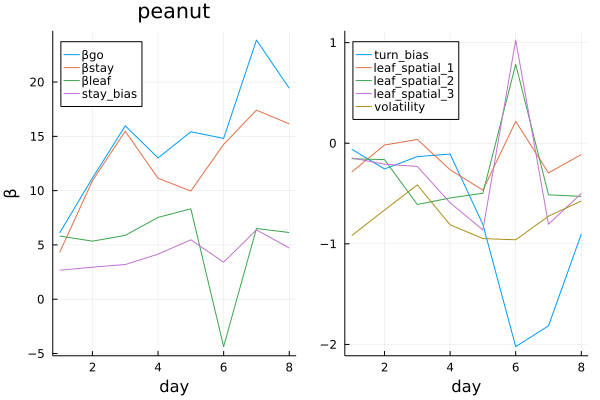

In [18]:
p1 = plot()
for i in 1:4
    plot!(hmm_leaf_stay_turn_leafspatial_peanut.x[:, i], label=hmm_leaf_stay_turn_leafspatial_peanut.varnames[i], legend=:topleft)
end
title!("peanut")
xlabel!("day")
ylabel!("β")

p2 = plot()
for i in 5:9
    plot!(hmm_leaf_stay_turn_leafspatial_peanut.x[:, i], label=hmm_leaf_stay_turn_leafspatial_peanut.varnames[i], legend=:topleft)
end
# title!("peanut (by day)")
xlabel!("day")
plot(p1, p2)

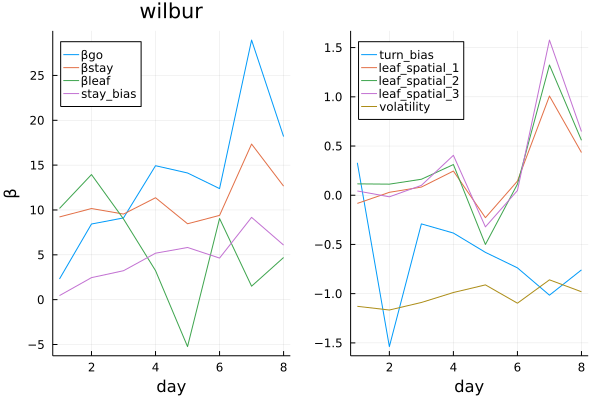

In [19]:
p1 = plot()
for i in 1:4
    plot!(hmm_leaf_stay_turn_leafspatial_wilbur.x[:, i], label=hmm_leaf_stay_turn_leafspatial_wilbur.varnames[i], legend=:topleft)
end
title!("wilbur")
xlabel!("day")
ylabel!("β")

p2 = plot()
for i in 5:9
    plot!(hmm_leaf_stay_turn_leafspatial_wilbur.x[:, i], label=hmm_leaf_stay_turn_leafspatial_wilbur.varnames[i], legend=:topleft)
end
# title!("wilbur (by day)")
xlabel!("day")
plot(p1, p2)

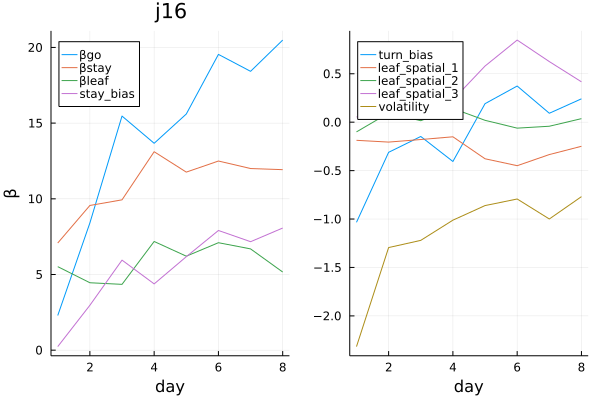

In [20]:
p1 = plot()
for i in 1:4
    plot!(hmm_leaf_stay_turn_leafspatial_j16.x[:, i], label=hmm_leaf_stay_turn_leafspatial_j16.varnames[i], legend=:topleft)
end
title!("j16")
xlabel!("day")
ylabel!("β")

p2 = plot()
for i in 5:9
    plot!(hmm_leaf_stay_turn_leafspatial_j16.x[:, i], label=hmm_leaf_stay_turn_leafspatial_j16.varnames[i], legend=:topleft)
end
# title!("j16 (by day)")
xlabel!("day")
plot(p1, p2)

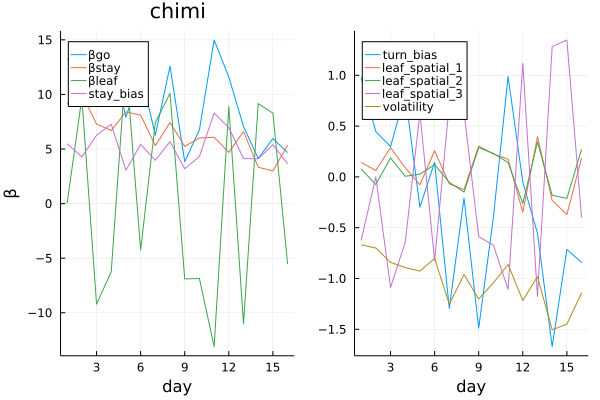

In [21]:
p1 = plot()
for i in 1:4
    plot!(hmm_leaf_stay_turn_leafspatial_chimi.x[:, i], label=hmm_leaf_stay_turn_leafspatial_chimi.varnames[i], legend=:topleft)
end
title!("chimi")
xlabel!("day")
ylabel!("β")

p2 = plot()
for i in 5:9
    plot!(hmm_leaf_stay_turn_leafspatial_chimi.x[:, i], label=hmm_leaf_stay_turn_leafspatial_chimi.varnames[i], legend=:topleft)
end
# title!("chimi (by day)")
xlabel!("day")
plot(p1, p2)

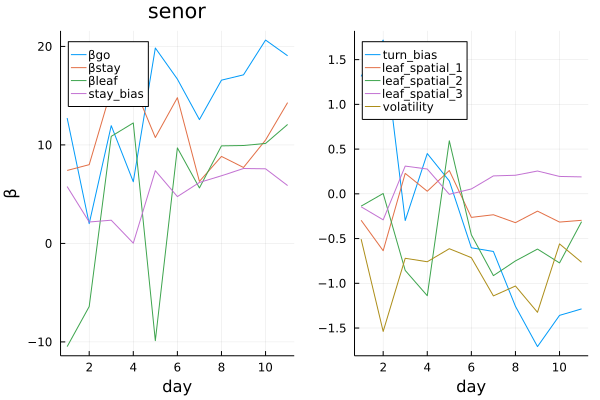

In [22]:
p1 = plot()
for i in 1:4
    plot!(hmm_leaf_stay_turn_leafspatial_senor.x[:, i], label=hmm_leaf_stay_turn_leafspatial_senor.varnames[i], legend=:topleft)
end
title!("senor")
xlabel!("day")
ylabel!("β")

p2 = plot()
for i in 5:9
    plot!(hmm_leaf_stay_turn_leafspatial_senor.x[:, i], label=hmm_leaf_stay_turn_leafspatial_senor.varnames[i], legend=:topleft)
end
# title!("senor (by day)")
xlabel!("day")
plot(p1, p2)

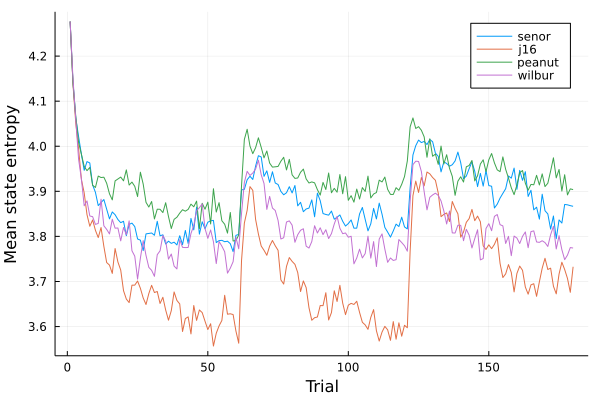

In [23]:
p = plot()
for animal in animals[[1,3,4,5]]
    df = CSV.read("results/Q_vals_leaf_stay_turn_leafspatial_$(animal).csv", DataFrame)
    plot!(combine(groupby(df, :trial), :state_entropy=>mean=>:state_entropy)[1:180,:state_entropy], label=animal)
end
p
ylabel!("Mean state entropy")
xlabel!("Trial")
# plot([!,:entropy])

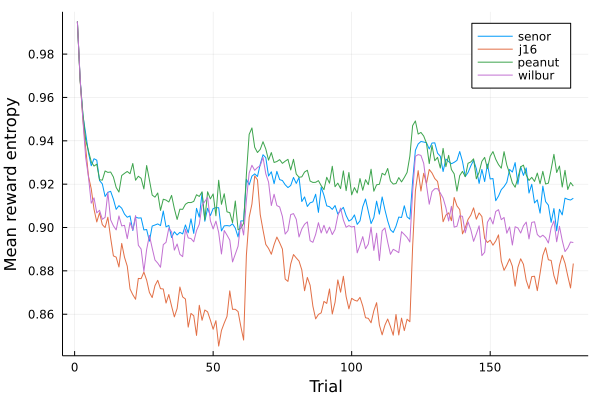

In [24]:
p = plot()
for animal in animals[[1,3,4,5]]
    df = CSV.read("results/Q_vals_leaf_stay_turn_leafspatial_$(animal).csv", DataFrame)
    plot!(combine(groupby(df, :trial), :reward_entropy=>mean=>:reward_entropy)[1:180,:reward_entropy], label=animal)
end
p
ylabel!("Mean reward entropy")
xlabel!("Trial")
# plot([!,:entropy])

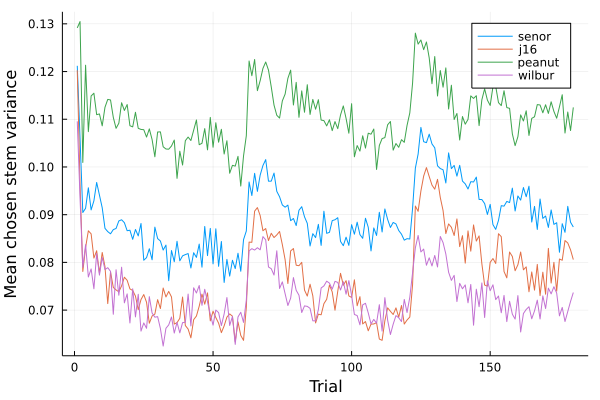

In [25]:
p = plot()
for animal in animals[[1,3,4,5]]
    df = CSV.read("results/Q_vals_leaf_stay_turn_leafspatial_$(animal).csv", DataFrame)
    plot!(combine(groupby(df, :trial), :stemchoice_var=>mean=>:stemchoice_var)[1:180,:stemchoice_var], label=animal)
end
p
ylabel!("Mean chosen stem variance")
xlabel!("Trial")
# plot([!,:entropy])